In [1]:
import matplotlib.pyplot as plt
from src.process_data import *

In [2]:
# ====== Parâmetros do experimento ======
type_perc = 'bond'
num_colors = 3
dim = 2
L = 2000
Nt = 200
k = 1.0e-04
rho = 8.9e-02

path_data = f"../Data/{type_perc}_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.1e}/data"
all_data = glob.glob(os.path.join(path_data, "*.json"))

out_dir = Path(path_data)
out_dir.mkdir(parents=True, exist_ok=True)

out_dat = out_dir / "all_data.dat"
out_txt = out_dir / "process_names.txt"

df, processed = saving_data(
    all_data=all_data,
    output_data=out_dat,
    output_names=out_txt,
    burn_in_frac=0.20,
    verbose=False,
    path_hint=path_data,          # <<< usa o path para extrair type_perc, L, Nt, k, rho...
)

print("Salvo em:", out_dat.resolve())
print("Processados:", len(processed))

[INFO] .dat salvo em: /home/junior/Documents/self_organization_percolation/Data/bond_percolation/num_colors_3/dim_2/L_2000/NT_constant/NT_200/k_1.0e-04/rho_8.9e-02/data/all_data.dat
[INFO] process_names.txt atualizado com 100 nomes: /home/junior/Documents/self_organization_percolation/Data/bond_percolation/num_colors_3/dim_2/L_2000/NT_constant/NT_200/k_1.0e-04/rho_8.9e-02/data/process_names.txt
Salvo em: /home/junior/Documents/self_organization_percolation/Data/bond_percolation/num_colors_3/dim_2/L_2000/NT_constant/NT_200/k_1.0e-04/rho_8.9e-02/data/all_data.dat
Processados: 100


In [7]:
path_data = f"../Data/{type_perc}_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.1e}/data"
df = pd.read_csv(path_data + "/all_data.dat", sep='\t')
df

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,p_mean,IC95,erro
0,bond,3,2,2000,200,0.0001,0.089,1.0,1,100,0.989460,"(0.988817492780398, 0.9901025888037006)",0.000328
1,bond,3,2,2000,200,0.0001,0.089,1.0,2,100,0.987568,"(0.9869211553252185, 0.9882144959752065)",0.000330
2,bond,3,2,2000,200,0.0001,0.089,1.0,3,99,0.987064,"(0.9864393152740927, 0.9876885794110755)",0.000319


Contagens (linhas = ordem, colunas = cor):


,cor 1,cor 2,cor 3
ordem 1,32,31,37
ordem 2,26,39,35
ordem 3,42,29,28



Percentuais por ordem (%):


,cor 1,cor 2,cor 3
ordem 1,32.0,31.0,37.0
ordem 2,26.0,39.0,35.0
ordem 3,42.4,29.3,28.3


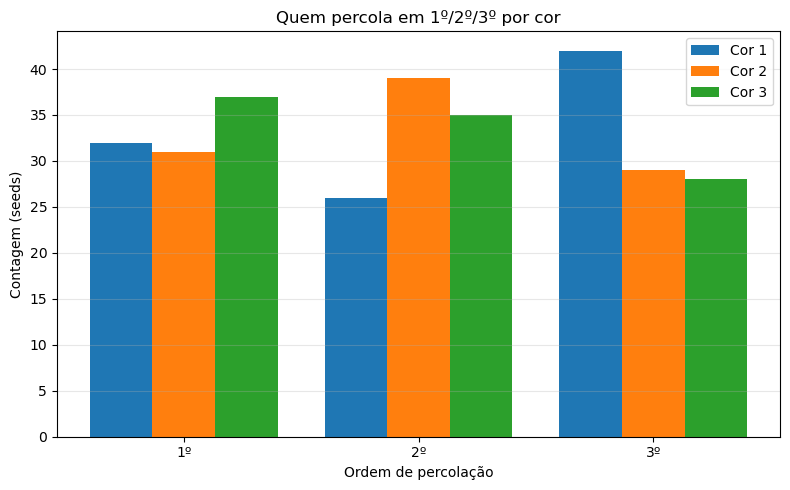

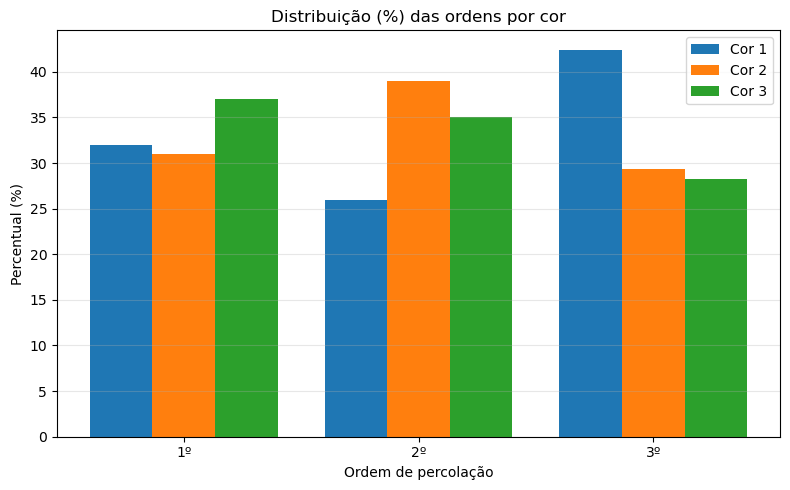

In [46]:
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ajuste se necessário
num_colors = 3

# counts[ordem-1, cor-1] = nº de vezes
counts = np.zeros((num_colors, num_colors), dtype=int)

for jf in all_data:  # sua lista de arquivos .json (seeds)
    try:
        with open(jf, "r") as f:
            obj = json.load(f)
        results = obj.get("results", [])
        if not isinstance(results, list) or not results:
            print(f"[WARN] sem 'results' em {os.path.basename(jf)}")
            continue

        for item in results:
            order = item.get("order_percolation")
            d = item.get("data", {})
            color = d.get("color")
            if isinstance(order, int) and isinstance(color, int):
                if 1 <= order <= num_colors and 1 <= color <= num_colors:
                    counts[order-1, color-1] += 1
    except Exception as e:
        print(f"[WARN] {os.path.basename(jf)}: {e}")

# Tabelas (contagens e % por ordem)
index = [f"ordem {i}" for i in range(1, num_colors+1)]
columns = [f"cor {j}" for j in range(1, num_colors+1)]
df_counts = pd.DataFrame(counts, index=index, columns=columns)
df_rowpct = df_counts.div(df_counts.sum(axis=1), axis=0) * 100

print("Contagens (linhas = ordem, colunas = cor):")
display(df_counts)
print("\nPercentuais por ordem (%):")
display(df_rowpct.round(1))

# --- Histograma (contagens) ---
x = np.arange(1, num_colors+1)
width = 0.8 / num_colors

plt.figure(figsize=(8,5))
for j in range(num_colors):
    plt.bar(x + (j - (num_colors-1)/2)*width,
            counts[:, j],
            width=width,
            label=f"Cor {j+1}")
plt.xticks(x, [f"{i}º" for i in x])
plt.xlabel("Ordem de percolação")
plt.ylabel("Contagem (seeds)")
plt.title("Quem percola em 1º/2º/3º por cor")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- (Opcional) Histograma em % por ordem ---
plt.figure(figsize=(8,5))
rowpct_vals = df_rowpct.values
for j in range(num_colors):
    plt.bar(x + (j - (num_colors-1)/2)*width,
            rowpct_vals[:, j],
            width=width,
            label=f"Cor {j+1}")
plt.xticks(x, [f"{i}º" for i in x])
plt.xlabel("Ordem de percolação")
plt.ylabel("Percentual (%)")
plt.title("Distribuição (%) das ordens por cor")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
